In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/student.csv")
X = df.drop(columns=["exam_score", "student_id"])
y = df["exam_score"]

target ayırma

In [4]:
X = pd.get_dummies(X, drop_first=True)

kategorik encoding(3 tane object):gender,academic_level,internet_quality

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train test split


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scaling(ölçeklendirme)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

ilk model


In [8]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.8163921795584242
MAE: 3.963319441755498


Değerlendirme
r2 sınav sonucunun varyansın %81 ini açıklayabiliyor.Bu:
ML projeleri için yüksek performans gösterebileceğini,
Linear Regression için oldukça iyi olduğunu,
Veri ile hedef arasında güçlü ilişki olduğunu gösterir.

mae değeri gerçek sınav puanından yaklaşık 4 puan sapıyor

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

productivity_score      0.811155
burnout_level           0.049972
focus_index             0.029746
social_media_hours      0.011108
sleep_hours             0.010553
online_classes_hours    0.010532
caffeine_intake_mg      0.010376
exercise_minutes        0.010302
screen_time_hours       0.010126
self_study_hours        0.009419
dtype: float64

özelliğin önemi
productivy_score %80 önemine sahip bu da sınav sonucuyla çok güçlü bir ilişki olduğunu gösterir

In [10]:
import joblib
joblib.dump(rf, "../models/exam_model.pkl")

['../models/exam_model.pkl']

exam modelinin kaydedilmesi productivity skorunu çıkararak model2 oluşturarak performans farklılığına bakılabilir.

In [11]:
y = df["burnout_level"]
X = df.drop(columns=["burnout_level", "student_id"])

In [12]:
X = pd.get_dummies(X, drop_first=True)

Encoding


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train/test olarak ayırma

In [14]:
from sklearn.ensemble import RandomForestRegressor

burnout_model = RandomForestRegressor(random_state=42)
burnout_model.fit(X_train, y_train)

burnout_pred = burnout_model.predict(X_test)

Model eğitme

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, burnout_pred))
print("MAE:", mean_absolute_error(y_test, burnout_pred))

R2: 0.79883864214364
MAE: 5.0645773


Burnout tahmin modeli, tükenmişlik seviyesindeki değişimin %79’unu açıklayabilmektedir. Bu sonuç öğrencinin yaşam tarzı ve akademik değişkenlerinin mental tükenmişlik üzerinde önemli etkileri olduğunu göstermektedir.

mae=5 puan hata yapılıyor

In [16]:
joblib.dump(burnout_model, "../models/burnout_model.pkl")

['../models/burnout_model.pkl']

In [17]:
print("Train R2:", burnout_model.score(X_train, y_train))

Train R2: 0.9706053683542627


Modelde overfiiting gözlemlend, ve hiperparametre optimazasyonu dengelendi

In [18]:
from sklearn.ensemble import RandomForestRegressor

burnout_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

burnout_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [19]:
print("Train R2:", burnout_model.score(X_train, y_train))
print("Test R2:", r2_score(y_test, burnout_model.predict(X_test)))

Train R2: 0.9252423740263676
Test R2: 0.8018083591295574


In [20]:
import pandas as pd

importances = pd.Series(
    burnout_model.feature_importances_,
    index=X.columns
)

importances = importances.sort_values(ascending=False)

importances.head(10)

sleep_hours             0.282300
upcoming_deadline       0.275645
part_time_job           0.146507
screen_time_hours       0.135049
caffeine_intake_mg      0.050534
exercise_minutes        0.029800
exam_score              0.013696
gaming_hours            0.008119
social_media_hours      0.008055
online_classes_hours    0.008047
dtype: float64

Feature importance analizi modelin karar mekanizmasını anlamak,literatür ile karşılaştırma yapabilmek için,gereksiz değişkenleri tespit etmek için hangi faktörlerin üzerinde durmamız ile ilgili

1.Sleep Hours
Uyku süresi burnout tahmininde en kritik faktör.Model sonuçlarına göre uyku süresi, tükenmişlik düzeyini belirlemede en etkili değişken olarak bulunmuştur. Bu durum, literatürde yer alan uyku eksikliğinin psikolojik tükenmişlik üzerindeki etkisini desteklemektedir.(Literatür araştırması yapılacak)
2.Zaman baskısı
3.Part-time
4.Ekran süresi

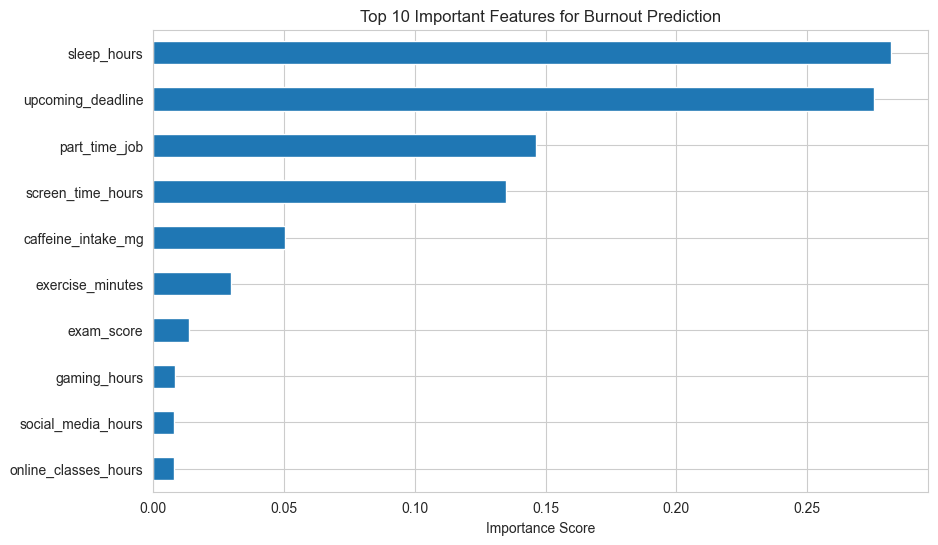

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features for Burnout Prediction")
plt.xlabel("Importance Score")
plt.show()

In [22]:
df[["screen_time_hours", 
    "social_media_hours", 
    "gaming_hours"]].corr()

,screen_time_hours,social_media_hours,gaming_hours
screen_time_hours,1.000000,-0.016412,-0.005403
social_media_hours,-0.016412,1.000000,0.010251
gaming_hours,-0.005403,0.010251,1.000000


Screen time değişkeni sosyal medya ve oyun süresinden bağımsız üretilmiş olup, model tarafından daha güçlü bir belirleyici olarak seçilmiştir. Bu durum toplam ekran maruziyetinin burnout üzerindeki etkisinin, ekranın kullanım türünden daha baskın olabileceğini göstermektedir.

In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("CV Mean R2:", scores.mean())

CV Mean R2: 0.8476456898193394


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [29]:
import sys
!{sys.executable} -m pip install shap

     -------------------------------------- 548.0/548.0 kB 1.0 MB/s eta 0:00:00
     -------------------------------------- 78.4/78.4 kB 873.5 kB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 646.9 kB/s eta 0:00:00
     ---------------------------------------- 38.1/38.1 MB 1.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [33]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

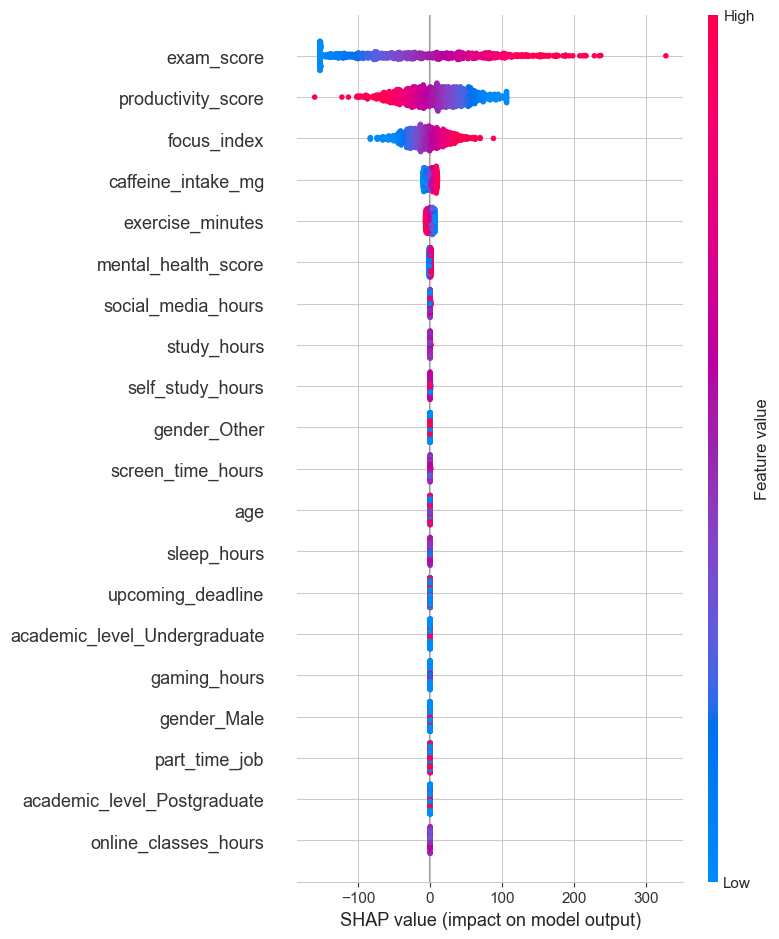

In [34]:
shap.summary_plot(shap_values.values, X_test)


In [35]:
print(X.columns)

Index(['age', 'study_hours', 'self_study_hours', 'online_classes_hours',
       'social_media_hours', 'gaming_hours', 'sleep_hours',
       'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg',
       'part_time_job', 'upcoming_deadline', 'mental_health_score',
       'focus_index', 'productivity_score', 'exam_score', 'gender_Male',
       'gender_Other', 'academic_level_Postgraduate',
       'academic_level_Undergraduate', 'internet_quality_Good',
       'internet_quality_Poor'],
      dtype='object')
